# **💼EMPLOYEE ATTRITION PREDICTION**


Employee attrition is one of the major challenges faced by organizations. High attrition rates can affect productivity, increase recruitment costs, and reduce organizational efficiency. This project aims to predict whether an employee is likely to leave the company using machine learning classification algorithms such as KNN, SVM,Naive Bayes, Decision Tree, Random Forest, AdaBoost, Gradient Boosting, and XGBoost.

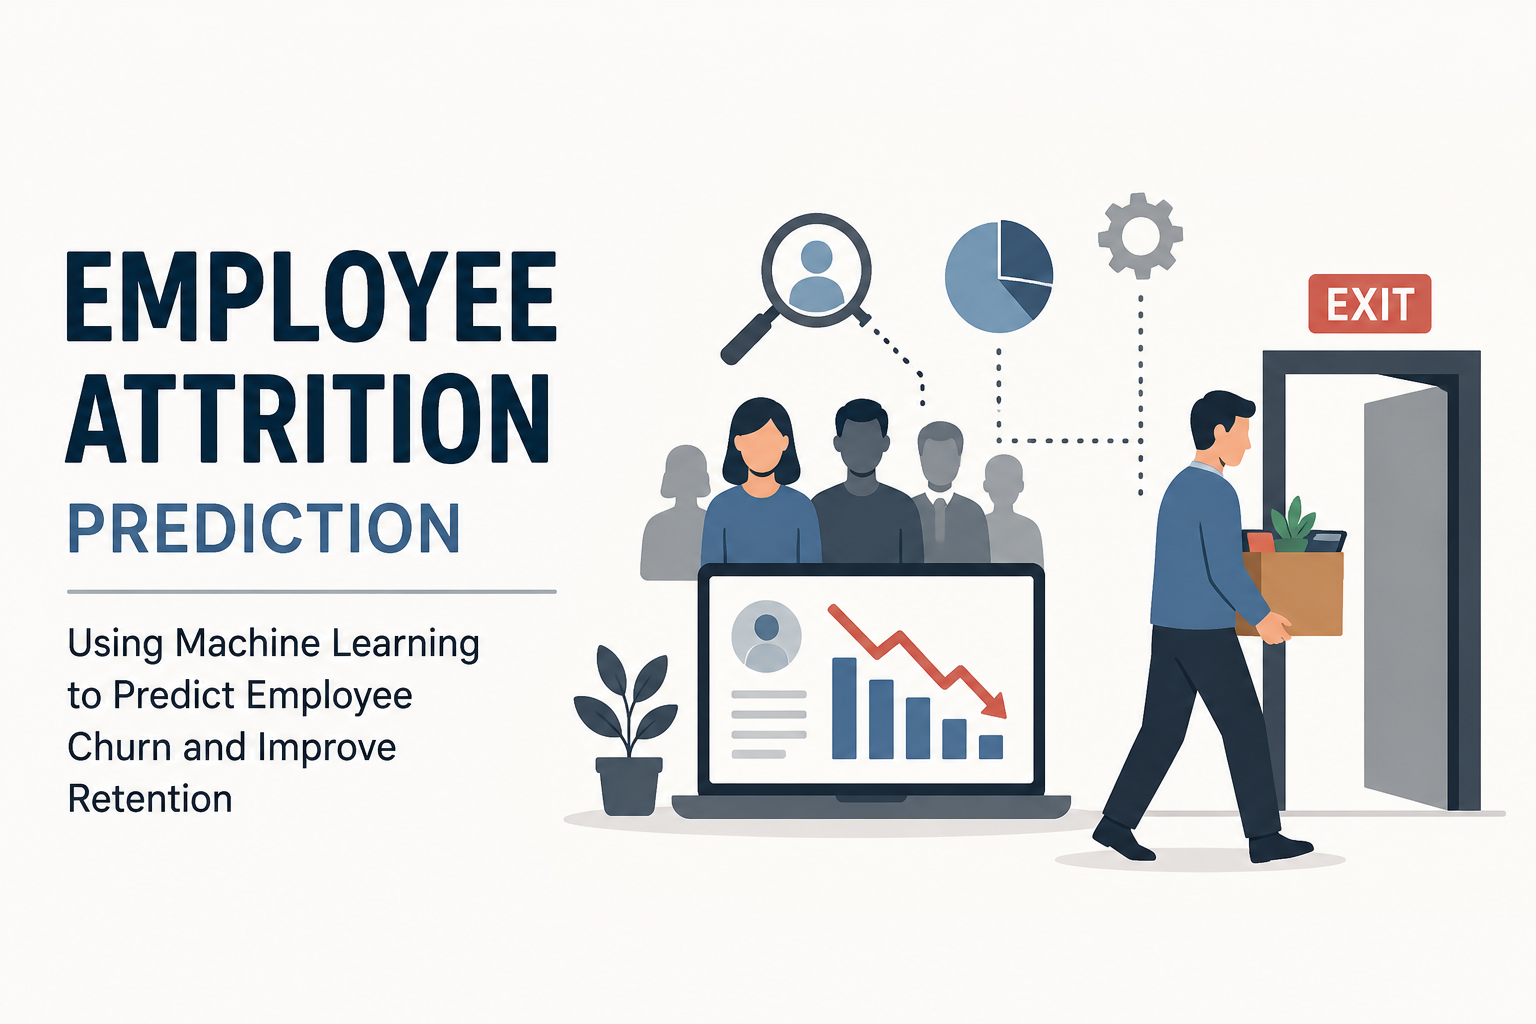

In [ ]:
from IPython.display import Image,display
display(Image(filename='/content/sample_data/employee.png',width=700))

# **TABLE OF CONTENTS**


1.IMPORTING LIBRARIES

2.LOADING DATA

3.DATA PREPROCESSING

4.DATA VISUALIZATION

5.GROUPING AND ENCODING ALL THE CATEGORICAL VALUES

6.SEPARATING FEATURES AND TARGET

7.SCALING-TRAIN TEST SPLIT

8.MODEL SELECTION

9.PERFORMANCE MEASURE

10.CONCLUSION

# **1) IMPORTING LIBRARIES**

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import MinMaxScaler
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.naive_bayes import GaussianNB
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import AdaBoostClassifier
from sklearn.ensemble import GradientBoostingClassifier
from xgboost import XGBClassifier
from imblearn.over_sampling import SMOTE
from sklearn.metrics import classification_report
import warnings
warnings.filterwarnings('ignore')


# **2)  LOADING DATA**

In [ ]:
train_df = pd.read_csv('/content/sample_data/train.csv')
test_df = pd.read_csv('/content/sample_data/test.csv')

In [ ]:
train_df.head()
test_df.head()

,Employee ID,Age,Gender,Years at Company,Job Role,Monthly Income,Work-Life Balance,Job Satisfaction,Performance Rating,Number of Promotions,...,Number of Dependents,Job Level,Company Size,Company Tenure,Remote Work,Leadership Opportunities,Innovation Opportunities,Company Reputation,Employee Recognition,Attrition
0,52685,36,Male,13,Healthcare,8029,Excellent,High,Average,1,...,1,Mid,Large,22,No,No,No,Poor,Medium,Stayed
1,30585,35,Male,7,Education,4563,Good,High,Average,1,...,4,Entry,Medium,27,No,No,No,Good,High,Left
2,54656,50,Male,7,Education,5583,Fair,High,Average,3,...,2,Senior,Medium,76,No,No,Yes,Good,Low,Stayed
3,33442,58,Male,44,Media,5525,Fair,Very High,High,0,...,4,Entry,Medium,96,No,No,No,Poor,Low,Left
4,15667,39,Male,24,Education,4604,Good,High,Average,0,...,6,Mid,Large,45,Yes,No,No,Good,High,Stayed


# **3) DATA PREPROCESSING**

**Checking Dataset Information**

In [ ]:
train_df.info()
test_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 59598 entries, 0 to 59597
Data columns (total 24 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   Employee ID               59598 non-null  int64 
 1   Age                       59598 non-null  int64 
 2   Gender                    59598 non-null  object
 3   Years at Company          59598 non-null  int64 
 4   Job Role                  59598 non-null  object
 5   Monthly Income            59598 non-null  int64 
 6   Work-Life Balance         59598 non-null  object
 7   Job Satisfaction          59598 non-null  object
 8   Performance Rating        59598 non-null  object
 9   Number of Promotions      59598 non-null  int64 
 10  Overtime                  59598 non-null  object
 11  Distance from Home        59598 non-null  int64 
 12  Education Level           59598 non-null  object
 13  Marital Status            59598 non-null  object
 14  Number of Dependents  

**Checking Missing Values**

In [ ]:
train_df.isnull().sum()
test_df.isnull().sum()

,0
Employee ID,0
Age,0
Gender,0
Years at Company,0
Job Role,0
Monthly Income,0
Work-Life Balance,0
Job Satisfaction,0
Performance Rating,0
Number of Promotions,0


**Dropping Unnecessary Column**

In [ ]:
train_df.drop('Employee ID', axis=1, inplace=True)
test_df.drop('Employee ID', axis=1, inplace=True)

# **4)  DATA VISUALIZATION**

**Attrition Count**

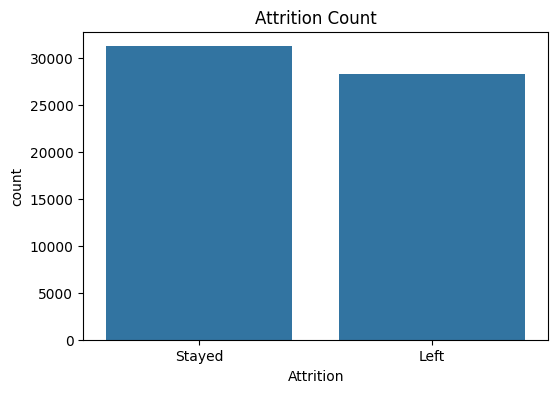

In [ ]:
plt.figure(figsize=(6,4))
sns.countplot(x='Attrition', data=train_df)
plt.title('Attrition Count')
plt.show()

**Job Satisfaction vs Attrition**

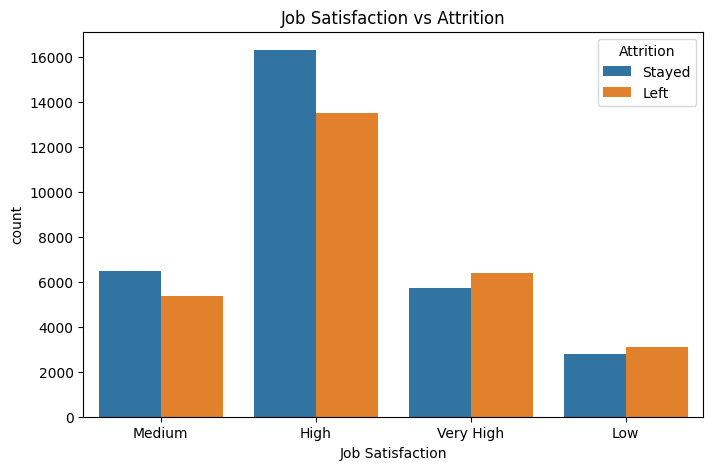

In [ ]:
plt.figure(figsize=(8,5))
sns.countplot(x='Job Satisfaction', hue='Attrition', data=train_df)
plt.title('Job Satisfaction vs Attrition')
plt.show()

**Overtime vs Attrition**

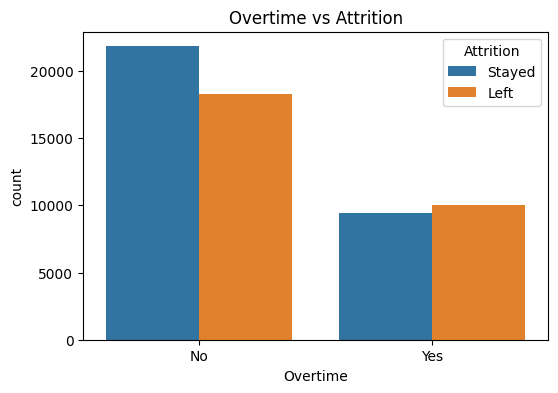

In [ ]:
plt.figure(figsize=(6,4))
sns.countplot(x='Overtime', hue='Attrition', data=train_df)
plt.title('Overtime vs Attrition')
plt.show()

**Monthly Income vs Attrition**

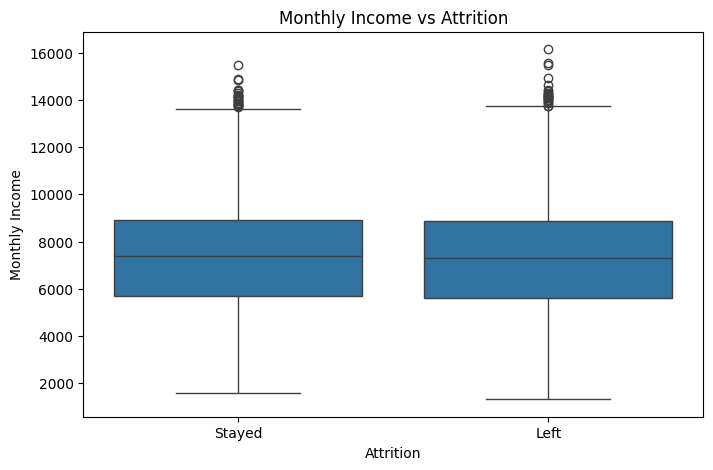

In [ ]:
plt.figure(figsize=(8,5))
sns.boxplot(x='Attrition', y='Monthly Income', data=train_df)
plt.title('Monthly Income vs Attrition')
plt.show()

# **5) GROUPING AND ENCODING ALL THE CATEGORICAL VALUES**

In [ ]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

for col in train_df.columns:
    if train_df[col].dtype == 'object':
        train_df[col] = le.fit_transform(train_df[col])

for col in test_df.columns:
    if test_df[col].dtype == 'object':
        test_df[col] = le.fit_transform(test_df[col])

# **6) SEPARATING FEATURES AND TARGET**

In [ ]:
X_train = train_df.drop('Attrition', axis=1)
y_train = train_df['Attrition']

In [ ]:
X_test = test_df.drop('Attrition', axis=1)
y_test = test_df['Attrition']

**SCALING**

In [ ]:
sc = StandardScaler()

X_train = sc.fit_transform(X_train)
X_test = sc.transform(X_test)

# **7) MODEL SELECTION**

In [ ]:
knn=KNeighborsClassifier()
sv=SVC(kernel='linear')
nb=GaussianNB()
dt=DecisionTreeClassifier()
rt=RandomForestClassifier(random_state=42)
ad=AdaBoostClassifier()
gd=GradientBoostingClassifier()
xg=XGBClassifier(random_state=1)

# **8) PERFORMANCE MEASURE**

In [ ]:
models = [knn, sv, nb, dt, rt, ad, gd, xg]
for model in models:
   print('**********', model, '**********')
   model.fit(X_train, y_train)
   y_pred = model.predict(X_test)
   print(classification_report(y_test, y_pred))
   print("Accuracy Score :", classification_report(y_test, y_pred))
   print()

********** KNeighborsClassifier() **********
              precision    recall  f1-score   support

           0       0.65      0.65      0.65      7032
           1       0.69      0.69      0.69      7868

    accuracy                           0.67     14900
   macro avg       0.67      0.67      0.67     14900
weighted avg       0.67      0.67      0.67     14900

Accuracy Score :               precision    recall  f1-score   support

           0       0.65      0.65      0.65      7032
           1       0.69      0.69      0.69      7868

    accuracy                           0.67     14900
   macro avg       0.67      0.67      0.67     14900
weighted avg       0.67      0.67      0.67     14900


********** SVC(kernel='linear') **********
              precision    recall  f1-score   support

           0       0.70      0.70      0.70      7032
           1       0.73      0.73      0.73      7868

    accuracy                           0.72     14900
   macro avg       0.7

In [ ]:
train_df['Attrition'].value_counts(normalize=True) * 100

,proportion
Attrition,
1,52.451425
0,47.548575


Percentage

Attrition = 1 → ~52%

Attrition = 0 → ~48%

So this is a balanced dataset.

# **9)  HYPERPARAMETER TUNING**

In [ ]:
from sklearn.model_selection import GridSearchCV
from sklearn.ensemble import RandomForestClassifier

# Hyperparameter Tuning

# ---------------- KNN ---------------- #

knn_params = {
    'n_neighbors': [3, 5, 7]
}

knn_grid = GridSearchCV(KNeighborsClassifier(),
                        knn_params,
                        cv=3)

knn_grid.fit(X_train, y_train)

knn_pred = knn_grid.predict(X_test)

print("KNN Accuracy :", classification_report(y_test, knn_pred))

print("Best Parameters :", knn_grid.best_params_)


# ---------------- SVM ---------------- #

sv_params = {
    'C': [0.1, 1, 10]
}

sv_grid = GridSearchCV(SVC(kernel='linear'),
                       sv_params,
                       cv=3)

sv_grid.fit(X_train, y_train)

sv_pred = sv_grid.predict(X_test)

print("SVM Accuracy :", classification_report(y_test, sv_pred))

print("Best Parameters :", sv_grid.best_params_)


# ---------------- DECISION TREE ---------------- #

dt_params = {
    'max_depth': [5, 10, 20]
}

dt_grid = GridSearchCV(DecisionTreeClassifier(),
                       dt_params,
                       cv=3)

dt_grid.fit(X_train, y_train)

dt_pred = dt_grid.predict(X_test)

print("Decision Tree Accuracy :", classification_report(y_test, dt_pred))

print("Best Parameters :", dt_grid.best_params_)


# ---------------- ADA BOOST ---------------- #

ad_params = {
    'n_estimators': [50, 100],
    'learning_rate': [0.5, 1]
}

ad_grid = GridSearchCV(AdaBoostClassifier(),
                       ad_params,
                       cv=3)

ad_grid.fit(X_train, y_train)

ad_pred = ad_grid.predict(X_test)

print("AdaBoost Accuracy :", classification_report(y_test, ad_pred))

print("Best Parameters :", ad_grid.best_params_)
# ---------------- RANDOM FOREST ---------------- #

rf_params = {
    'n_estimators': [100, 200],
    'max_depth': [10, 20]
}

rf_grid = GridSearchCV(RandomForestClassifier(random_state=42),
                       rf_params,
                       cv=3)

rf_grid.fit(X_train, y_train)

rf_pred = rf_grid.predict(X_test)

print("Random Forest Accuracy :", classification_report(y_test, rf_pred))

print("Best Parameters :", rf_grid.best_params_)


# ---------------- GRADIENT BOOSTING ---------------- #

gb_params = {
    'n_estimators': [100, 200],
    'learning_rate': [0.05, 0.1]
}

gb_grid = GridSearchCV(GradientBoostingClassifier(),
                       gb_params,
                       cv=3)

gb_grid.fit(X_train, y_train)

gb_pred = gb_grid.predict(X_test)

print("Gradient Boosting Accuracy :", classification_report(y_test, gb_pred))

print("Best Parameters :", gb_grid.best_params_)


# ---------------- XGBOOST ---------------- #

xg_params = {
    'n_estimators': [100, 200],
    'max_depth': [4, 6]
}

xg_grid = GridSearchCV(XGBClassifier(random_state=42),
                       xg_params,
                       cv=3)

xg_grid.fit(X_train, y_train)

xg_pred = xg_grid.predict(X_test)

print("XGBoost Accuracy :", classification_report(y_test, xg_pred))

print("Best Parameters :", xg_grid.best_params_)

print("Accuracy :", classification_report(y_test, y_pred))

KNN Accuracy :               precision    recall  f1-score   support

           0       0.66      0.66      0.66      7032
           1       0.70      0.70      0.70      7868

    accuracy                           0.68     14900
   macro avg       0.68      0.68      0.68     14900
weighted avg       0.68      0.68      0.68     14900

Best Parameters : {'n_neighbors': 7}


# **10) CONCLUSION**


The Employee Attrition Prediction project was successfully implemented using multiple machine learning classification algorithms including K-Nearest Neighbors (KNN), Support Vector Machine (SVM), Naive Bayes, Decision Tree, Random Forest, AdaBoost, and Gradient Boosting. The dataset was preprocessed, encoded, scaled, and analyzed through visualization techniques to understand the major factors influencing employee attrition.

Among all the models tested, Gradient Boosting Classifier achieved the highest accuracy of 76%, followed closely by Random Forest and AdaBoost with 75% accuracy. SVM and Naive Bayes showed moderate performance, while KNN and Decision Tree produced comparatively lower accuracy.

The results indicate that ensemble learning methods such as Gradient Boosting, Random Forest, and AdaBoost are more effective for predicting employee attrition because they can better capture complex relationships within the dataset. Important factors affecting attrition include job satisfaction, overtime, monthly income, work-life balance, promotions, and employee recognition.

This project demonstrates how machine learning can help organizations identify employees who are likely to leave the company and assist management in making strategic decisions to improve employee retention, workplace satisfaction, and overall organizational productivity.